In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from vis import make_yref
# from sklearn.preprocessing import StandardScaler
from util import concat_hrf, group_by_dict_fields
import os
import globals as gl
from pcm_models import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
from statsmodels.stats.anova import AnovaRM
import pickle
import pingouin as pg
from matplotlib import colormaps as cm
# from vis import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, add_significance_bars, set_spines_and_ticks_width, add_noise_ceiling, make_yref, load_border_vertices_xml
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib.lines import Line2D
import os
import globals as gl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import pandas as pd
import seaborn as sns
import nibabel as nb
import numpy as np
import nitools as nt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import pyvista as pv
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_1samp

import nitools as nt

plt.style.use('default')

In [11]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'R'
experiment1 = 'smp2'

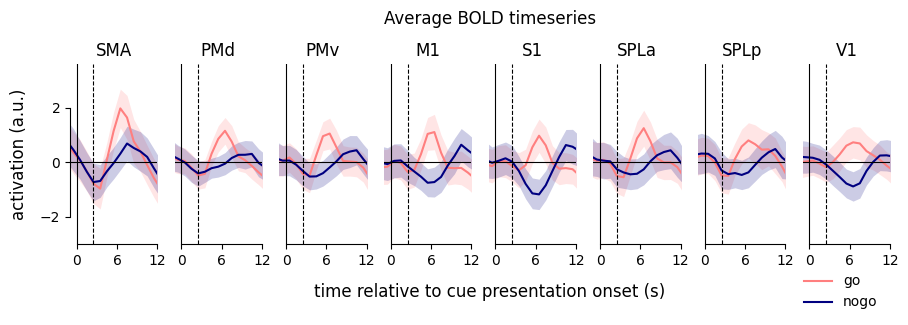

In [12]:
from vis import plot_bold

rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
sns = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
Ts = [os.path.join(gl.baseDir, experiment1, f'glm{glm}', f'subj{sn}', 'T.mat') for sn in sns]
T = concat_hrf(Ts)

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 3))
fig, axs = plot_bold(fig, axs, T, H, rois)

plt.show()

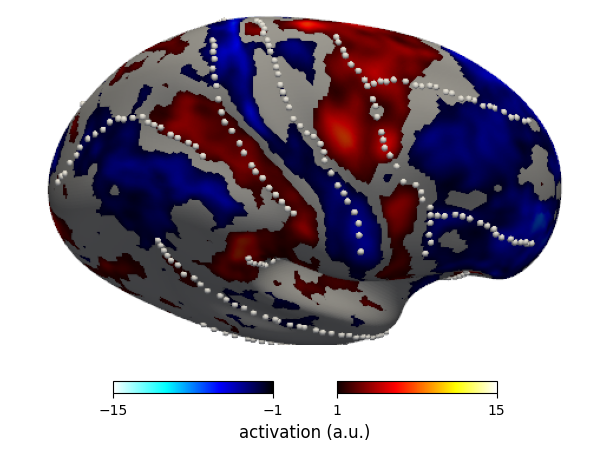

In [13]:
from vis import plot_surf

cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)

dtype = 'con'
thresh = 1
vmin, vmax = -15, 15

cifti = nb.load(os.path.join(gl.baseDir, experiment1, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)

cold_half = LinearSegmentedColormap.from_list("cold_half", combined[:128])
hot_half = LinearSegmentedColormap.from_list("hot_half", combined[128:])

neg_norm = Normalize(vmin=vmin, vmax=-thresh)
sm_neg = ScalarMappable(norm=neg_norm, cmap=cold_half)
cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

pos_norm = Normalize(vmin=thresh, vmax=vmax)
sm_pos = ScalarMappable(norm=pos_norm, cmap=hot_half)
cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

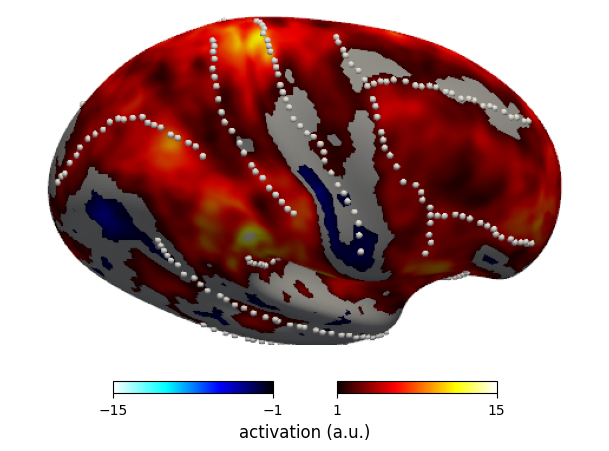

In [14]:
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)

cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

ROI: SMA
planning vs. execution: TtestResult(statistic=np.float64(0.9101145902992097), pvalue=np.float64(0.37932758473296524), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(2.982625902721425), pvalue=np.float64(0.01058672464698272), df=np.int64(13))
execution vs. 0: TtestResult(statistic=np.float64(3.2079444317938566), pvalue=np.float64(0.0068618379315287074), df=np.int64(13))
ROI: PMd
planning vs. execution: TtestResult(statistic=np.float64(0.8801689843660704), pvalue=np.float64(0.3947480158715425), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(3.017669895017858), pvalue=np.float64(0.009896785962082516), df=np.int64(13))
execution vs. 0: TtestResult(statistic=np.float64(2.704390835991715), pvalue=np.float64(0.018042262383335558), df=np.int64(13))
ROI: PMv
planning vs. execution: TtestResult(statistic=np.float64(1.2005971567420435), pvalue=np.float64(0.2513278430878994), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(1.47925760

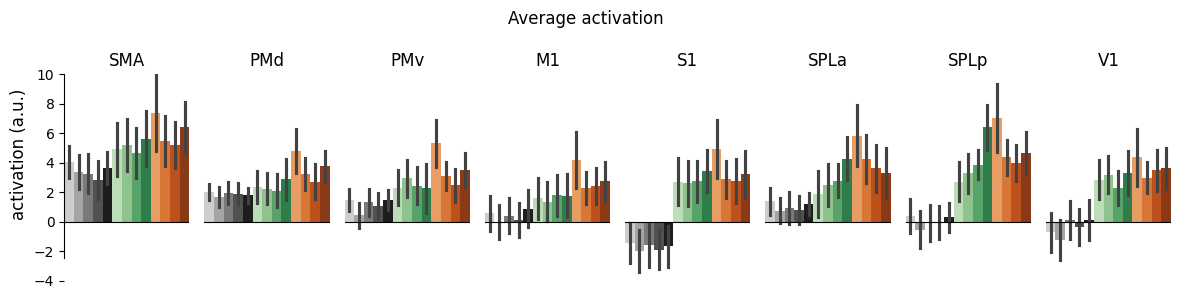

In [15]:
from vis import plot_avg_activation

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment1, f'glm{glm}','ROI.con.avg.tsv'), sep='\t')
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(12, 3))
fig, axs = plot_avg_activation(fig, axs, df_con, H, rois)
axs[0].set_ylim((-4, 10))
axs[0].spines[['left', ]].set_bounds(-2.5, 10)
df_con_stat = df_con.groupby(['sn', 'roi', 'Hem', 'epoch']).mean(numeric_only=True).reset_index()
for roi in rois:
    plan = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'plan')]['con']
    exec = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'exec')]['con']
    print(f'ROI: {roi}')
    print(f'planning vs. execution: {ttest_rel(exec, plan)}')
    print(f'planning vs. 0: {ttest_1samp(plan, 0)}')
    print(f'execution vs. 0: {ttest_1samp(exec, 0)}')
fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activation')
fig.tight_layout()

SMA: tval=3.7043048639303056, pval=0.002648222185694069
PMd: tval=5.99658597714964, pval=4.4707995184748015e-05
PMv: tval=3.696480141963526, pval=0.002688023933548488
M1: tval=3.660367900529507, pval=0.002879754208980062
S1: tval=3.1759003888085964, pval=0.0072984778750182265
SPLa: tval=5.035752108329004, pval=0.00022810134236414992
SPLp: tval=4.585893990302223, pval=0.0005106325526953423
V1: tval=4.43485031414195, pval=0.0006730923381258246


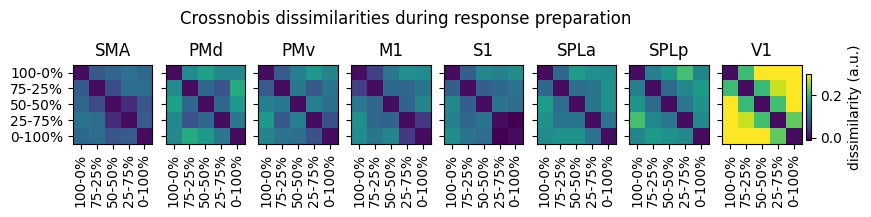

In [16]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .3

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
im = axs[-1].images[0]
fig.colorbar(im, cax=cbar_ax).set_label('dissimilarity (a.u.)', )
fig.suptitle('Crossnobis dissimilarities during response preparation')

plt.show()

SMA: 0.7846326175809135 upper noise
PMd: 0.8925649566484991 upper noise
PMv: 0.5735019936608953 upper noise
M1: 0.7231378436565671 upper noise
S1: 0.789822455007344 upper noise
SPLa: 0.8850668486470722 upper noise
SPLp: 0.7718298271831311 upper noise
V1: 0.9095357336992325 upper noise
SMA, tval=2.6988270460042636, pval=0.009117351390697382
PMd, tval=4.1085098328382665, pval=0.0006166631676958928
PMv, tval=2.747054137596213, pval=0.008315594573464133
M1, tval=1.8721115955102796, pval=0.041928455878967534
S1, tval=2.323187733220736, pval=0.01851455389198517
SPLa, tval=2.771987722263891, pval=0.007928590730746324
SPLp, tval=3.390948303578884, pval=0.0024127633900538864
V1, tval=3.491579491209963, pval=0.0019888819998013607


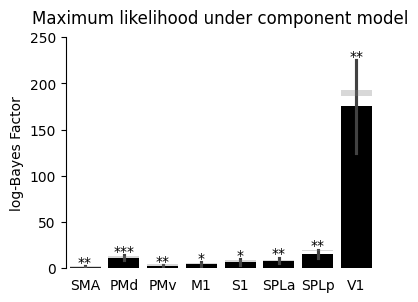

In [17]:
from vis import plot_likelihood

LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_cv.plan.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_gr.plan.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 250)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
cue, tval=1.628136609293843, pval=0.06373862392336371
uncertainty, tval=2.6816500830450902, pval=0.009420777659611468
cue vs. uncertainty, tval=0.10168943689661925, pval=0.9205549226387862

PMd:
cue, tval=1.9390889014404418, pval=0.03725344876244423
uncertainty, tval=3.8508936918407963, pval=0.0010020658319519894
cue vs. uncertainty, tval=-1.3746908360411245, pval=0.19246011620940023

PMv:
cue, tval=1.6331191393792515, pval=0.06320861573081862
uncertainty, tval=1.2731882357710786, pval=0.11262394226409686
cue vs. uncertainty, tval=0.8494077303663392, pval=0.41102433517086834

M1:
cue, tval=2.101395026863044, pval=0.027835727350508932
uncertainty, tval=2.0724024615200256, pval=0.02933712443067384
cue vs. uncertainty, tval=1.2874276709821304, pval=0.22039414552582076

S1:
cue, tval=2.921573734433107, pval=0.005952236968215022
uncertainty, tval=1.095322185511312, pval=0.14662680975278017
cue vs. uncertainty, tval=1.7299712411946204, pval=0.1072886204774371

SPLa:
cue, tval=2.9747967

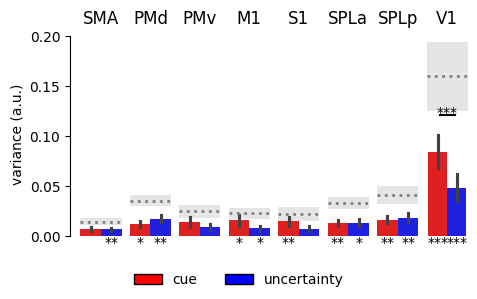

In [18]:
from vis import plot_var_expl, add_sig_var_expl, add_sig_comp_bayes

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'M.plan.p'), 'component')
n_param_c = Mc.n_param
components = ['cue', 'uncertainty']
palette = ['red', 'blue']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(5, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

SMA: tval=6.169671050819244, pval=3.3792506556511165e-05
PMd: tval=4.462246937714121, pval=0.0006400709213993271
PMv: tval=3.2397017642989603, pval=0.006454922108353205
M1: tval=4.941801828035639, pval=0.00026932587497946914
S1: tval=4.830535576902755, pval=0.0003283819047692518
SPLa: tval=3.38902755429563, pval=0.004843371051040809
SPLp: tval=6.708832817405508, pval=1.4508503617821537e-05
V1: tval=5.450526395456752, pval=0.00011112082189919491


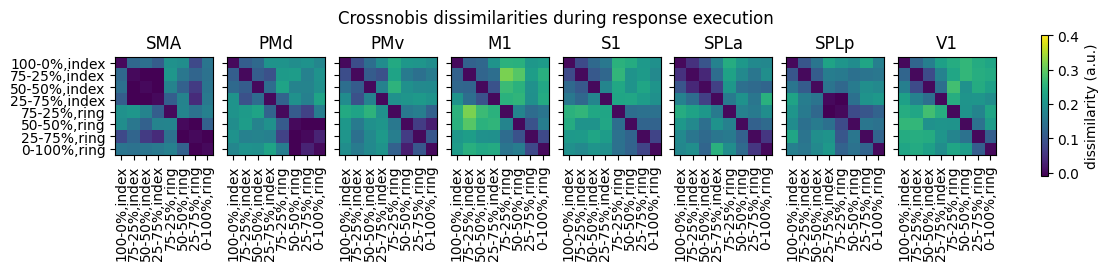

In [19]:
vmin, vmax = -.01, .4

fig, axs = plt.subplots(1, len(rois), figsize=(11, 2.5),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

SMA: 0.09392843478554923 upper noise
PMd: 0.10880271003212241 upper noise
PMv: 0.07701912396775551 upper noise
M1: 0.11293276928178039 upper noise
S1: 0.08623353894540367 upper noise
SPLa: 0.1343750354885075 upper noise
SPLp: 0.14396603393200819 upper noise
V1: 0.06254973306786328 upper noise
SMA, tval=3.932591171592178, pval=0.0008585315432062524
PMd, tval=5.4086805387598655, pval=5.967753366161696e-05
PMv, tval=4.096745630662185, pval=0.0006304039239313266
M1, tval=3.072816604679929, pval=0.004450237212759122
S1, tval=3.892847430817467, pval=0.000925525421521533
SPLa, tval=4.034592733411162, pval=0.0007084022323664614
SPLp, tval=4.061756832777037, pval=0.0006731607279991662
V1, tval=2.8166558798566905, pval=0.007278995438144598


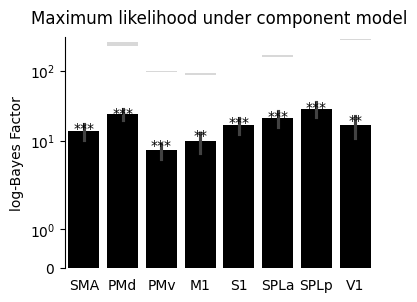

In [20]:
LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_cv.exec.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T_gr.exec.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 300)
axs.set_yscale('symlog')
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
finger, tval=2.1218158576471895, pval=0.026821470981422135
cue, tval=0.8939882096812697, pval=0.19378986725273262
surprise, tval=3.468641070802659, pval=0.0020783567952071488
finger vs. cue, tval=2.2877881679398624, pval=0.03954427527060119
finger vs. surprise, tval=-5.72812252688208, pval=6.958652902516948e-05
cue vs. surprise, tval=-7.513877526018624, pval=4.411503534035852e-06

PMd:
finger, tval=3.372945336629476, pval=0.002497706930327011
cue, tval=0.9435193412008562, pval=0.18131051388759728
surprise, tval=6.766636884068399, pval=6.641116075035643e-06
finger vs. cue, tval=2.00185604064809, pval=0.06661854762725987
finger vs. surprise, tval=-5.240584343423855, pval=0.00015944434353623203
cue vs. surprise, tval=-8.72666136074164, pval=8.525478181985496e-07

PMv:
finger, tval=1.9068096845587217, pval=0.039443883511573366
cue, tval=0.771949647330637, pval=0.22697462015798836
surprise, tval=3.536183399339356, pval=0.0018258967043621264
finger vs. cue, tval=2.277577175758992, pval

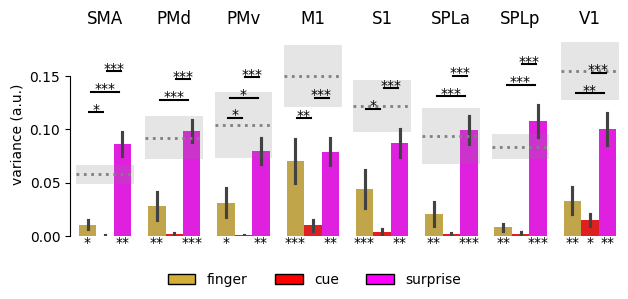

In [21]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['finger', 'cue', 'surprise']
palette = ['#D4AF37', 'red', 'magenta']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(7, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

SMA, tval=-3988810.4486746495, pval=5.83837992982678e-80
PMd, tval=-2046130.543594389, pval=3.4286498793881436e-76
PMv, tval=-2570024.282481974, pval=1.7704048476773606e-77
M1, tval=-40.75342173918679, pval=4.212891562483384e-15
S1, tval=-1531421.1356755954, pval=1.4826077329036256e-74
SPLa, tval=-55067.25789374814, pval=8.823515687500025e-56
SPLp, tval=-2350874.9878998934, pval=5.639915251621521e-77
V1, tval=-509663.87534644245, pval=2.4130507684721855e-68


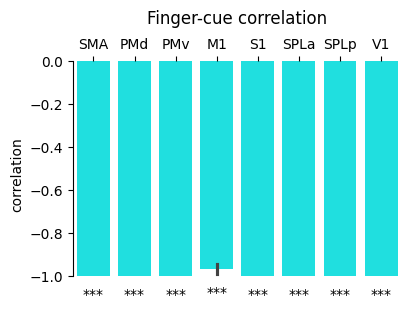

In [22]:
from vis import plot_interaction, add_sig_to_bars

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment1, gl.pcmDir, 'M.exec.p'), 'feature')
# Mc, idxc = find_model(os.path.join(gl.baseDir, experiment1, gl.pcmDir, 'M.exec.p'), 'component')
n_param_f = Mf.n_param
# n_param_c = Mc.n_param
interaction = {'roi': [], 'interaction': [],}
pcm_path = os.path.join(gl.baseDir, experiment1, gl.pcmDir)
for roi in rois:
    f = open(os.path.join(pcm_path, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    theta = param[idxf][:n_param_f]
    theta2 = theta ** 2
    covariance = theta[1] * theta[2]
    stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    correlation = covariance / stds
    interaction['roi'].extend([roi] * theta.shape[1])
    interaction['interaction'].extend(correlation if (np.isclose(stds, 0).sum() / stds.size) < .6 else [None] * theta.shape[1])

fig, ax = plt.subplots(figsize=(4, 3), constrained_layout=True)
fig, ax = plot_interaction(fig, ax, interaction)
fig, ax = add_sig_to_bars(fig, ax, interaction, y='interaction', x='roi')
ax.spines['left'].set_bounds(ax.get_yticks()[1], ax.get_yticks()[-1])
ax.set_title('Finger-cue correlation', pad=10)
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

SMA
group estimate:-0.9999999999979771 central 90% CI for r: [-1.000, -1.000]
PMd
group estimate:-0.9999999993331308 central 90% CI for r: [-1.000, -0.969]
PMv
group estimate:-1.0 central 90% CI for r: [-1.000, -0.603]
M1
group estimate:-0.04940863681800318 central 90% CI for r: [-1.000, 0.165]
S1
group estimate:-0.9428467311101282 central 90% CI for r: [-1.000, -0.283]
SPLa
group estimate:-1.0 central 90% CI for r: [-1.000, -0.655]
SPLp
group estimate:-0.8269835459987771 central 90% CI for r: [-1.000, -0.357]
V1
group estimate:0.24910561067073095 central 90% CI for r: [0.078, 0.398]


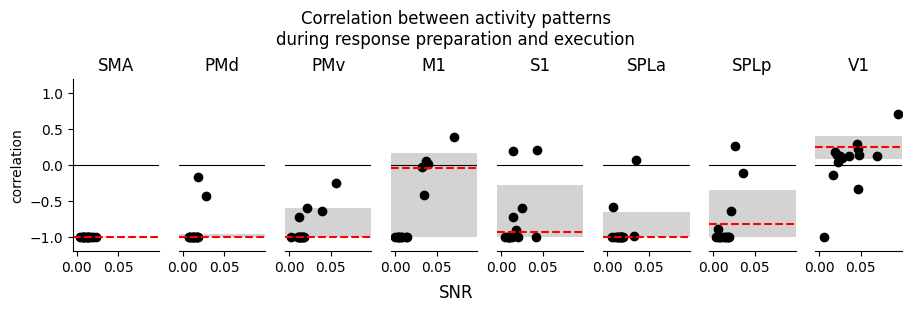

In [23]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)
rois_tmp = ['PMd','M1', 'S1','SPLa']

fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(9, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    print(roi)
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'r_bootstrap.{H}.{roi}.npy'))
    f = open(os.path.join(gl.baseDir, experiment1, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between activity patterns\nduring response preparation and execution')

plt.show()
